In [14]:
using HDF5
using PyPlot
using ProgressBars

In [15]:
# filename = "data/2025-07-04_0013_TwoDGas_00.h5";
pathdir = "data/04_07_25/0018/"
filenames = readdir(pathdir)[1:10]
plot_imgs = true
idx_img = 1
xc, yc, a, b, θ = 325, 340, 70, 40, 1.1;

# Load images

0.0%┣                                               ┫ 0/10 [00:00<00:00, -0s/it]
10.0%┣████▏                                     ┫ 1/10 [00:01<Inf:Inf, InfGs/it]
20.0%┣█████████▍                                     ┫ 2/10 [00:02<00:12, 2s/it]
30.0%┣██████████████                                 ┫ 3/10 [00:03<00:10, 1s/it]
40.0%┣██████████████████▉                            ┫ 4/10 [00:04<00:08, 1s/it]
50.0%┣███████████████████████▌                       ┫ 5/10 [00:05<00:07, 1s/it]
60.0%┣████████████████████████████▏                  ┫ 6/10 [00:06<00:05, 1s/it]
70.0%┣█████████████████████████████████              ┫ 7/10 [00:07<00:03, 1s/it]
80.0%┣█████████████████████████████████████▋         ┫ 8/10 [00:07<00:02, 1s/it]
90.0%┣██████████████████████████████████████████▎    ┫ 9/10 [00:08<00:01, 1s/it]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:09<00:00, 1it/s]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:09<00:00, 1it/s]


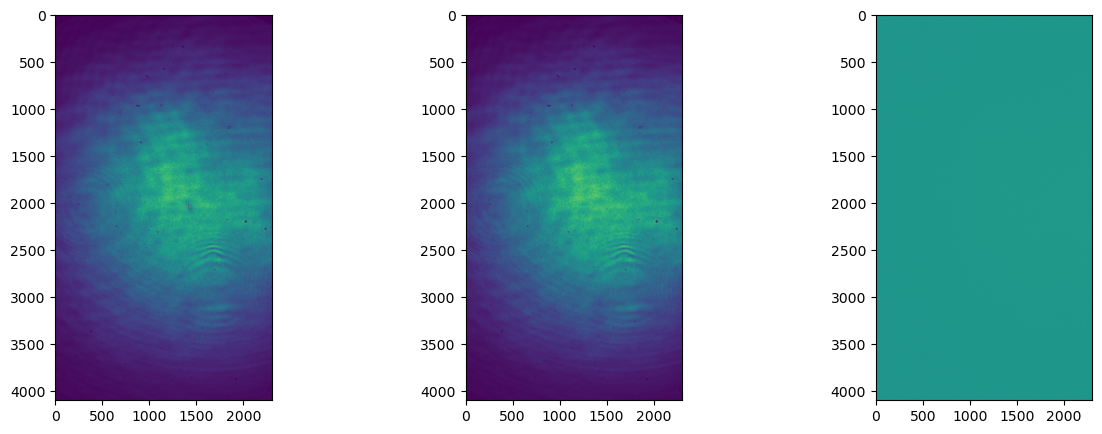

false

In [16]:
imgs_atoms, imgs_bkg, imgs_dark = [], [], []

for filename in ProgressBar(filenames)
    # println(filename)
    
    filename = pathdir*filename
    h5open(filename, "r") do file
        img_atoms = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"]))
        img_bkg = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"]))
        img_dark = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"]))
        push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark)
    end
end

if plot_imgs
    close("all")
    fig, axs = subplots(1, 3, figsize=(15, 5))
    axs[1].imshow(imgs_atoms[idx_img]), axs[2].imshow(imgs_bkg[idx_img]), axs[3].imshow(imgs_dark[idx_img])
    # pygui(true); show()
    pygui(false)
end

# Crop the image

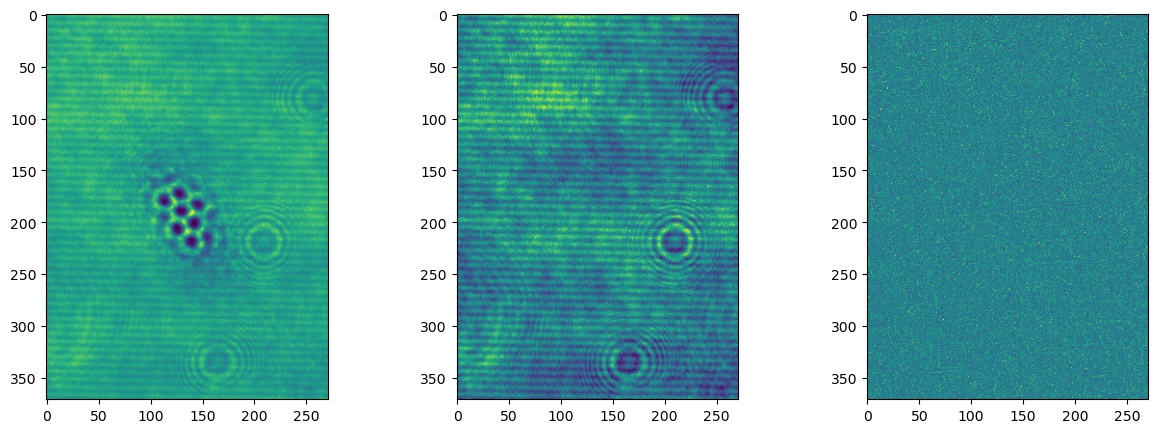

false

In [34]:
imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop = [], [], []

# x_crop = [1300:1600;]
# y_crop = [1900:2200;]

x_crop = [1290:1560;]
y_crop = [1840:2210;]

# x_crop = [1:size(imgs_atoms[1])[2];]
# y_crop = [1:size(imgs_atoms[1])[1];]

for i = 1:length(imgs_atoms)
    img_atoms_crop = imgs_atoms[i][y_crop, x_crop]
    img_bkg_crop = imgs_bkg[i][y_crop, x_crop]
    img_dark_crop = imgs_dark[i][y_crop, x_crop]
    push!(imgs_atoms_crop, img_atoms_crop), push!(imgs_bkg_crop, img_bkg_crop), push!(imgs_dark_crop, img_dark_crop)
end

if plot_imgs
    close("all")
    fig, axs = subplots(1, 3, figsize=(15, 5))
    axs[1].imshow(imgs_atoms_crop[idx_img]), axs[2].imshow(imgs_bkg_crop[idx_img]), axs[3].imshow(imgs_dark_crop[idx_img])
    pygui(false)
    # pygui(true); show()
end

# Compute OD

0.0%┣                                               ┫ 0/10 [00:00<00:00, -0s/it]
10.0%┣████▏                                     ┫ 1/10 [00:00<Inf:Inf, InfGs/it]
20.0%┣█████████▍                                     ┫ 2/10 [00:00<00:04, 2it/s]
30.0%┣██████████████                                 ┫ 3/10 [00:01<00:03, 3it/s]
40.0%┣██████████████████▉                            ┫ 4/10 [00:01<00:02, 3it/s]
50.0%┣███████████████████████▌                       ┫ 5/10 [00:01<00:02, 3it/s]
60.0%┣████████████████████████████▏                  ┫ 6/10 [00:02<00:01, 3it/s]
70.0%┣█████████████████████████████████              ┫ 7/10 [00:02<00:01, 3it/s]
80.0%┣█████████████████████████████████████▋         ┫ 8/10 [00:02<00:01, 3it/s]
90.0%┣██████████████████████████████████████████▎    ┫ 9/10 [00:02<00:00, 3it/s]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:03<00:00, 3it/s]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:03<00:00, 3it/s]


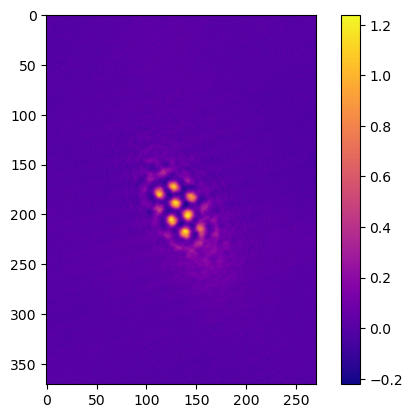

false

In [35]:
ODs = []
close("all")
fig, axs = subplots()
for i = ProgressBar(1:length(imgs_atoms))
    OD = (imgs_atoms_crop[i] .- imgs_dark_crop[i]) ./ (imgs_bkg_crop[i] .- imgs_dark_crop[i])
    OD[OD .< 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
    OD .= -log10.(OD)
    push!(ODs, OD)
    img = axs.imshow(OD, cmap="plasma") #, aspect="auto"
    cb = colorbar(img)
    savefig("imgs/ODs/$i.png")
    cb.remove()
    axs.clear()
end

if plot_imgs
    close("all")
    fig, axs = subplots()
    img = axs.imshow(ODs[idx_img], cmap="plasma") #, aspect="auto"
    colorbar(img)
    pygui(false);
    # pygui(true); show()
end

# Sum the images

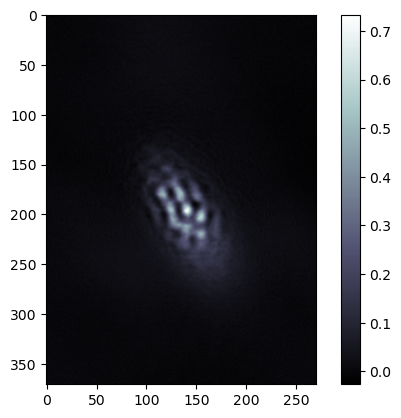

In [36]:
OD_sum = zeros(size(ODs[1]))
for OD in ODs
    OD_sum .+= OD
end
OD_sum ./= length(ODs)

close("all")
fig, axs = subplots()
img = axs.imshow(OD_sum, cmap="bone") #, aspect="auto"
colorbar(img)
pygui(false);
# pygui(true); show()

# Plot only negative ODs

0.0%┣                                               ┫ 0/10 [00:00<00:00, -0s/it]
10.0%┣████▏                                     ┫ 1/10 [00:00<Inf:Inf, InfGs/it]
20.0%┣█████████▍                                     ┫ 2/10 [00:00<00:04, 2it/s]
30.0%┣██████████████                                 ┫ 3/10 [00:01<00:03, 2it/s]
40.0%┣██████████████████▉                            ┫ 4/10 [00:01<00:02, 3it/s]
50.0%┣███████████████████████▌                       ┫ 5/10 [00:01<00:02, 3it/s]
60.0%┣████████████████████████████▏                  ┫ 6/10 [00:02<00:01, 3it/s]
70.0%┣█████████████████████████████████              ┫ 7/10 [00:02<00:01, 3it/s]
80.0%┣█████████████████████████████████████▋         ┫ 8/10 [00:02<00:01, 3it/s]
90.0%┣██████████████████████████████████████████▎    ┫ 9/10 [00:02<00:00, 3it/s]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:03<00:00, 3it/s]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:03<00:00, 3it/s]


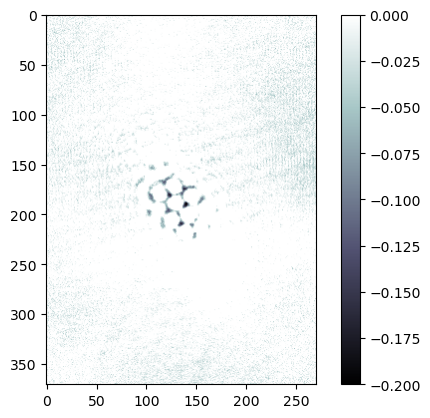

false

In [37]:
close("all")
fig, axs = subplots()

for i = ProgressBar(1:length(ODs))
    img = axs.imshow(ODs[i], cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto"
    cb = colorbar(img)
    savefig("imgs/neg_ODs/$i.png")
    cb.remove()
    axs.clear()
end

if plot_imgs
    close("all")
    fig, axs = subplots()
    img = axs.imshow(ODs[idx_img], cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto" cmap="plasma"
    colorbar(img)
    pygui(false);
    # pygui(true); show()
end

# Mask to keep only the condensate

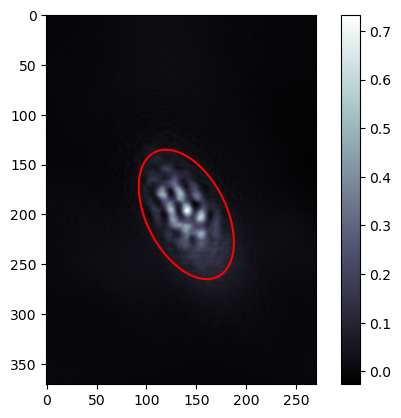

In [41]:
function ellipse(xc, yc, a, b, θ)
    res = []
    t = range(0, 2π, 100)
    return xc .+ a*cos.(t)*cos(θ) .- b*sin.(t)*sin(θ), yc .+ a*cos.(t)*sin(θ) + b*sin.(t)*cos(θ)
end

close("all")
fig, axs = subplots()
img = axs.imshow(OD_sum, cmap="bone") #, aspect="auto"
colorbar(img)

xc, yc, a, b, θ = 140, 200, 70, 40, 1.1;
ell = ellipse(xc, yc, a, b, θ)
axs.plot(ell[1], ell[2], color="r")

pygui(false);
# pygui(true); show()

In [55]:
function mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)
    mask = zeros(Integer, (length(y_crop), length(x_crop)))

    X = range(0, length(y_crop)-1) .- yc
    Y = range(0, length(x_crop)-1) .- xc

    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

mask_ellipse (generic function with 1 method)

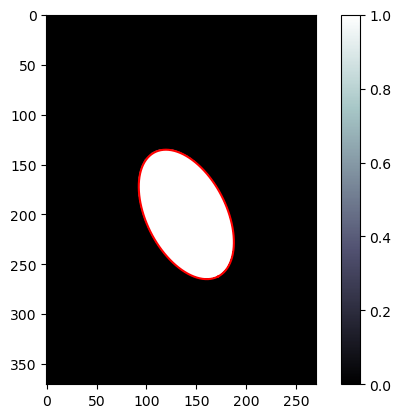

In [56]:
mask = mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)

close("all")
fig, axs = subplots()
img = axs.imshow(mask, cmap="bone") #, aspect="auto"
colorbar(img)
axs.plot(ell[1], ell[2], color="r")
pygui(false);
# pygui(true); show()

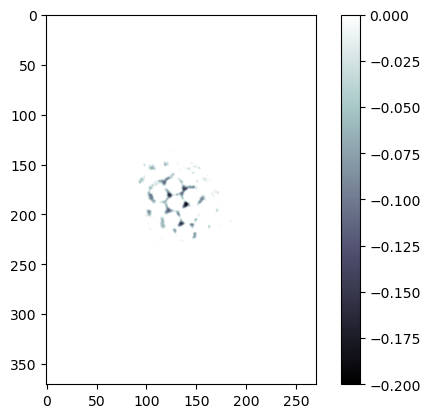

In [43]:
close("all")
fig, axs = subplots()
img = axs.imshow(ODs[idx_img] .* mask, cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto" cmap="plasma"
colorbar(img)
pygui(false);

# Brouillons

In [24]:
# ENV["PYTHON"] = "path/to/conda/envs/julia-py/python"